In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")


from src.CocoDataset import CocoDataset

ds = CocoDataset("../data/raw/football-players/train")


In [3]:
from src.equipos import colorRecorte
from src.viz import recortesTorso
import numpy as np

recortes = recortesTorso(ds, 20)
print(len(recortes))

colores = np.array([colorRecorte(r) for r in recortes])
print(colores)


24
[[185.  137.5 121. ]
 [212.  248.5 159. ]
 [161.  102.5  65. ]
 [173.5 189.  149.5]
 [140.  129.   83. ]
 [188.  142.  107. ]
 [ 58.   73.   40. ]
 [197.  137.  117. ]
 [192.  151.  134. ]
 [169.  223.  134. ]
 [183.  220.  153. ]
 [188.  242.  148. ]
 [195.5 228.5 157. ]
 [190.  119.5 117. ]
 [224.  175.5 150.5]
 [140.  201.5 101.5]
 [199.  237.  160. ]
 [173.  203.  151. ]
 [188.5 164.  169.5]
 [171.  200.  139. ]
 [202.  202.5 127. ]
 [192.5 165.5 121. ]
 [164.  221.  124.5]
 [ 95.   73.   58.5]]


/home/juan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


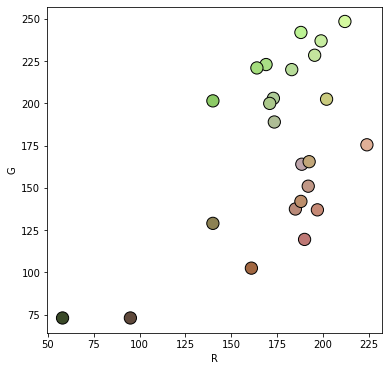

In [4]:
import matplotlib.pyplot as plt


plt.figure(figsize=(6, 6))
plt.scatter(colores[:, 0], colores[:, 1], c=colores/255, s=150, edgecolors="black")
plt.xlabel("R"); plt.ylabel("G")
plt.show()

In [5]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
from src.equipos import clasificarEquipos
from collections  import Counter


recortes20 = recortesTorso(ds, 20)
recortes65 = recortesTorso(ds, 65)
recortes137 = recortesTorso(ds, 137)

colores20 = np.array([colorRecorte(r) for r in recortes20])
colores65 = np.array([colorRecorte(r) for r in recortes65])
colores137 = np.array([colorRecorte(r) for r in recortes137])

cromaticidad20 = colores20 / colores20.sum(axis=1, keepdims=True)
cromaticidad65 = colores65 / colores65.sum(axis=1, keepdims=True)
cromaticidad137 = colores137 / colores137.sum(axis=1, keepdims=True)

clasificador20 = clasificarEquipos(cromaticidad20)
print(Counter(clasificador20))

clasificador65 = clasificarEquipos(cromaticidad65)
print(Counter(clasificador65))

clasificador137 = clasificarEquipos(cromaticidad137)
print(Counter(clasificador137))

Counter({np.int32(1): 13, np.int32(0): 11})
Counter({np.int32(0): 15, np.int32(1): 11})
Counter({np.int32(0): 19, np.int32(1): 6})


In [7]:
clases20 = [k for c, k in ds.cajas(20)]

for g in sorted(set(clasificador20)):
    print(g, Counter(k for k, e in zip(clases20, clasificador20) if e == g))

0 Counter({'player': 10, 'referee': 1})
1 Counter({'player': 10, 'referee': 1, 'ball': 1, 'goalkeeper': 1})


In [8]:
from sklearn.preprocessing import StandardScaler

X, clases = {}, {}

for img in (20, 65, 137):
    pares = [(c, k) for c, k in ds.cajas(img) if k != "ball"]
    cajas = [c for c, k in pares]
    clases[img] = [k for c, k in pares]

    col    = np.array([colorRecorte(r) for r in recortesTorso(ds, img, cajas)])
    crom   = col / col.sum(axis=1, keepdims=True)
    brillo = col.sum(axis=1, keepdims=True)

    X[img] = StandardScaler().fit_transform(np.hstack([crom[:, :2], brillo]))

for img in (20, 65, 137):
    et = clasificarEquipos(X[img], k=2)
    print(img, Counter(et))
    for g in sorted(set(et)):
        print("   ", g, Counter(k for k, e in zip(clases[img], et) if e == g))

print(X)

20 Counter({np.int32(0): 12, np.int32(1): 11})
    0 Counter({'player': 10, 'referee': 1, 'goalkeeper': 1})
    1 Counter({'player': 10, 'referee': 1})
65 Counter({np.int32(1): 13, np.int32(0): 12})
    0 Counter({'player': 10, 'referee': 1, 'goalkeeper': 1})
    1 Counter({'player': 10, 'referee': 2, 'goalkeeper': 1})
137 Counter({np.int32(1): 13, np.int32(0): 11})
    0 Counter({'player': 9, 'referee': 2})
    1 Counter({'player': 11, 'goalkeeper': 1, 'referee': 1})
{20: array([[ 0.86366995, -1.12396282, -0.2475265 ],
       [-0.67885737,  0.72668847,  1.35309215],
       [ 2.36595207, -1.08352444, -1.29338528],
       [-0.74770804,  0.07681367,  0.37544155],
       [ 0.46408169,  0.02270669, -1.07966631],
       [ 1.13274071, -0.8210816 , -0.30664026],
       [-0.74124148,  1.25022855, -2.72575708],
       [ 1.26864266, -1.25122683, -0.17931832],
       [ 0.56266454, -0.99134363,  0.05713671],
       [-1.10952355,  1.19037516,  0.50276349],
       [-0.94803592,  0.61604101,  0.77559

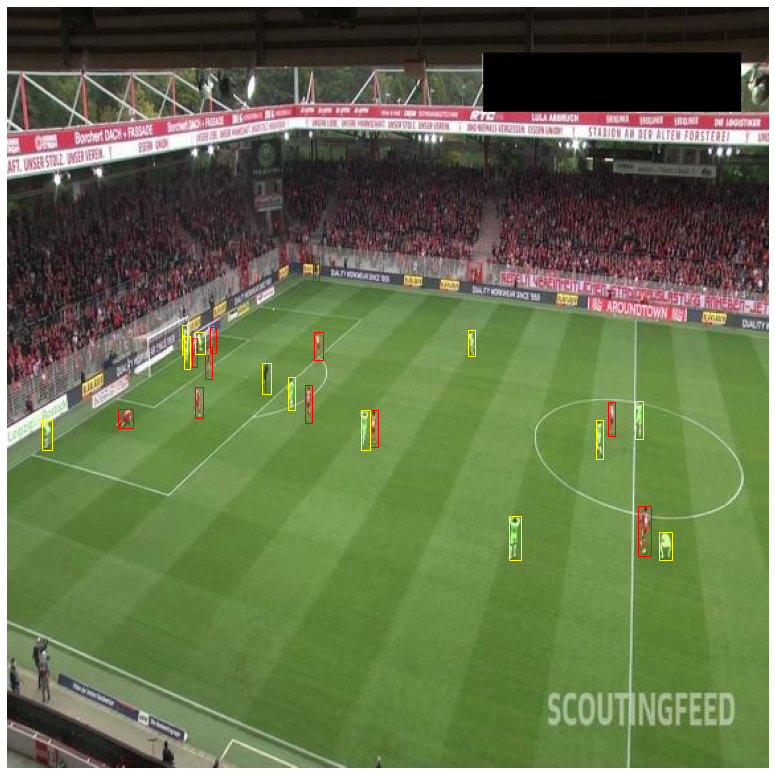

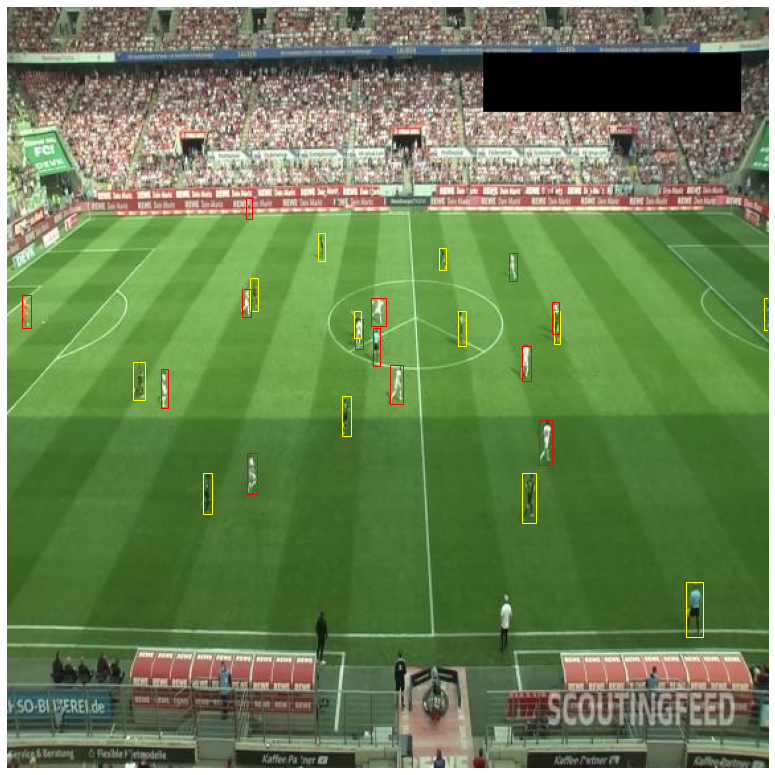

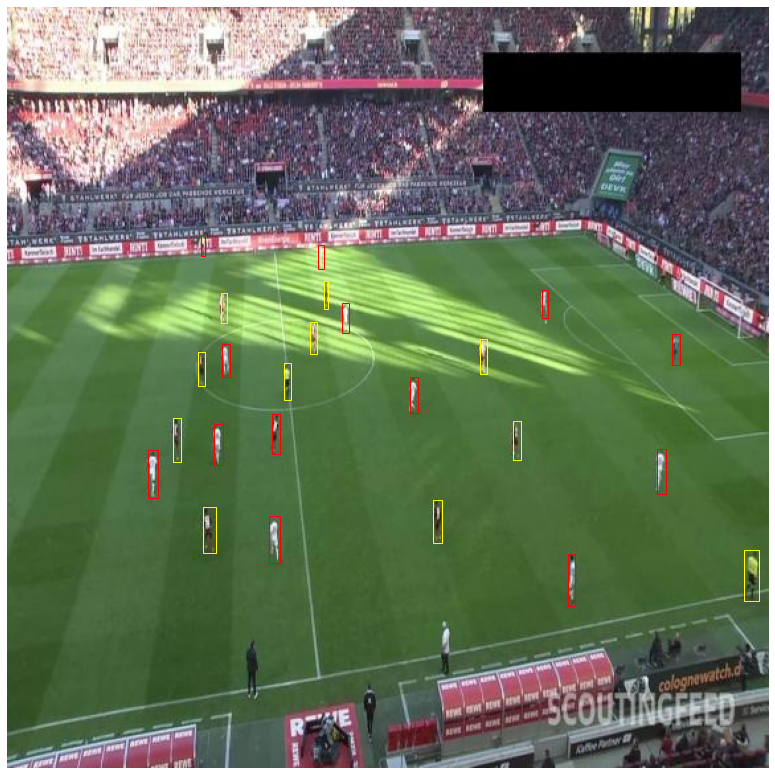

In [9]:
from src.viz import dibujarCajas

IMG = (20, 65, 137)

for imagen in IMG:

    cajas = [c for c, k in ds.cajas(imagen) if k != "ball"]
    et = clasificarEquipos(X[imagen], k=2)

    pares = [(caja, f"e{e}") for caja, e in zip(cajas, et)]

    fig, ax = plt.subplots(figsize=(14, 14))
    ax.imshow(ds.imagen(imagen))
    ax.axis("off")
    dibujarCajas(ax, pares, colores={"e0": "yellow", "e1" : "red"})
    plt.show()

In [10]:
print(ds.cajas(20))

[((139, 250, 143, 272), 'player'), ((493, 397, 502.5, 418), 'player'), ((83, 304, 95, 318.5), 'player'), ((132, 240, 135.5, 262), 'player'), ((149, 257, 154.5, 281.5), 'player'), ((142, 287, 147.5, 310.5), 'player'), ((192, 269, 199, 292.5), 'referee'), ((225, 286, 230.5, 314.5), 'player'), ((454, 299, 459.5, 324.5), 'player'), ((212, 280, 217.5, 305), 'player'), ((445, 312, 450.5, 341.5), 'player'), ((475, 298, 480.5, 326.5), 'player'), ((348, 244, 353.5, 263.5), 'player'), ((477, 377, 487, 415), 'player'), ((274, 305, 280, 332.5), 'player'), ((379, 385, 388.5, 418.5), 'player'), ((26, 312, 33.5, 335), 'player'), ((200, 227, 202.5, 232.5), 'ball'), ((153, 242, 157.5, 261.5), 'player'), ((133, 249, 138, 274), 'player'), ((142, 246, 149.5, 262), 'goalkeeper'), ((232, 246, 238.5, 266.5), 'player'), ((267, 305, 274, 335), 'player'), ((231, 189, 235.5, 207), 'referee')]


[((263, 103, 267.5, 125.5), 'e1'), ((124, 101, 129, 125), 'e0'), ((171, 125, 176.5, 150.5), 'e1'), ((225, 152, 232, 180.5), 'e1'), ((203, 181, 210, 215.5), 'e1'), ((397, 151, 402.5, 182.5), 'e1'), ((361, 118, 371, 144), 'e1'), ((251, 143, 258, 174), 'e1'), ((138, 151, 146.5, 184.5), 'e1'), ((106, 188, 114.5, 223), 'e1'), ((353, 157, 361, 188.5), 'e1'), ((264, 221, 271, 259.5), 'e0'), ((130, 411, 147.5, 469), 'e1'), ((213, 233, 221.5, 272.5), 'e1'), ((102, 177, 109, 209), 'e1'), ((345, 192, 353, 226.5), 'e1'), ((87, 237, 99.5, 278.5), 'e1'), ((328, 168, 335, 199), 'e1'), ((237, 235, 247.5, 273.5), 'e1'), ((98, 247, 108, 290), 'e1'), ((475, 298, 489.5, 344), 'e1'), ((82, 303, 96.5, 347.5), 'e0')]


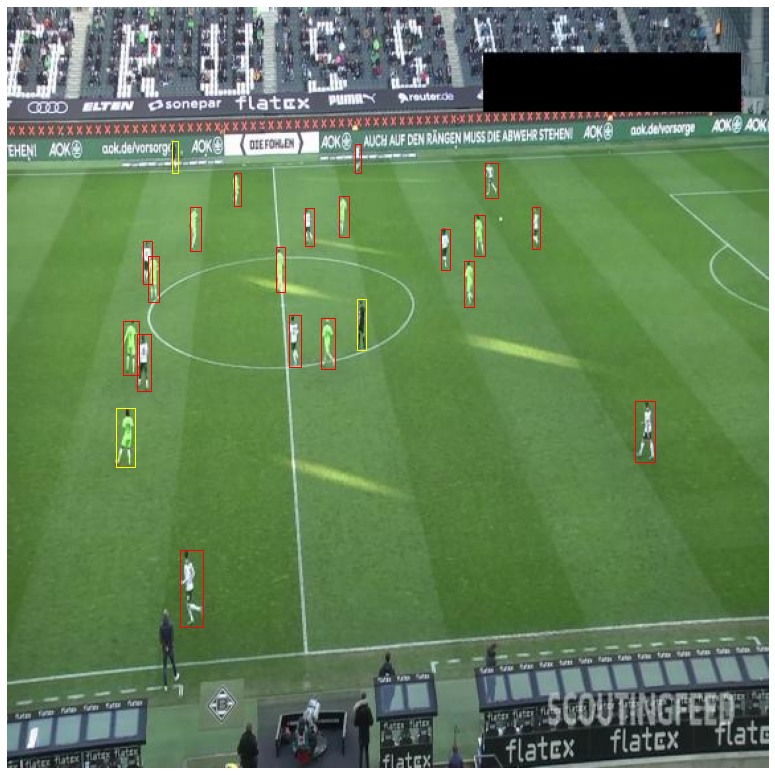

In [11]:
from src.pipeline import analizarImagen

IMG_ID = 100

pares = analizarImagen(ds, IMG_ID)
print(pares)

fig, ax = plt.subplots(figsize=(14, 14))
ax.imshow(ds.imagen(100))
ax.axis("off")
dibujarCajas(ax, pares, colores={"e0": "yellow", "e1": "red"})
plt.show()

In [12]:
from collections import Counter

desequilibrio = {}
for i in sorted(ds.id2fichero):
    c = Counter(e for _, e in analizarImagen(ds, i))
    if len(c) == 2:
        a, b = c.values()
        desequilibrio[i] = min(a, b) / max(a, b)     # 1.0 = perfecto

peores = sorted(desequilibrio.items(), key=lambda kv: kv[1])[:8]
print(peores)

[(202, 0.041666666666666664), (208, 0.041666666666666664), (150, 0.043478260869565216), (252, 0.043478260869565216), (268, 0.043478260869565216), (284, 0.043478260869565216), (14, 0.045454545454545456), (53, 0.045454545454545456)]


[((209, 154, 214, 179), 'e0'), ((390, 178, 395, 202), 'e0'), ((436, 185, 441.5, 214.5), 'e1'), ((349, 198, 356.5, 229.5), 'e0'), ((331, 197, 339.5, 224.5), 'e0'), ((431, 243, 440, 279.5), 'e0'), ((256, 169, 265.5, 192.5), 'e1'), ((239, 221, 245.5, 251), 'e1'), ((379, 212, 385.5, 243), 'e1'), ((408, 222, 414.5, 259), 'e0'), ((423, 251, 430.5, 291), 'e1'), ((263, 254, 274, 296), 'e1'), ((112, 281, 121.5, 325.5), 'e0'), ((511, 276, 521, 322), 'e1'), ((181, 220, 192.5, 256.5), 'e0'), ((237, 406, 247, 463), 'e1'), ((280, 258, 288, 296.5), 'e1'), ((475, 221, 484.5, 259), 'e1'), ((522, 263, 532.5, 306), 'e1'), ((491, 343, 504, 392.5), 'e0'), ((402, 331, 411, 381.5), 'e1'), ((530, 318, 541, 366.5), 'e1')]


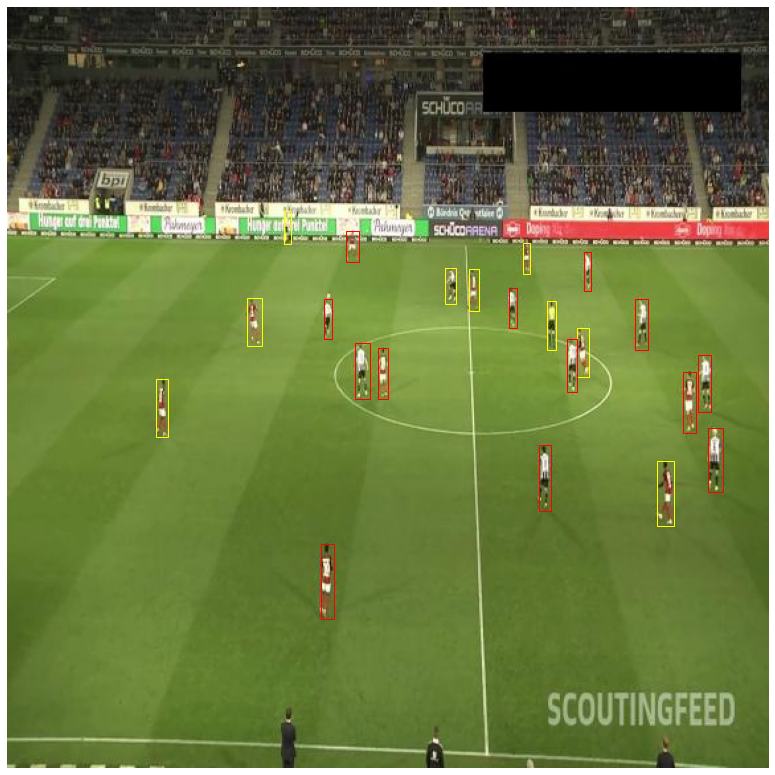

[((209, 154, 214, 179), 'e0'), ((390, 178, 395, 202), 'e0'), ((436, 185, 441.5, 214.5), 'e1'), ((349, 198, 356.5, 229.5), 'e0'), ((331, 197, 339.5, 224.5), 'e0'), ((431, 243, 440, 279.5), 'e0'), ((256, 169, 265.5, 192.5), 'e1'), ((239, 221, 245.5, 251), 'e1'), ((379, 212, 385.5, 243), 'e1'), ((408, 222, 414.5, 259), 'e0'), ((423, 251, 430.5, 291), 'e1'), ((263, 254, 274, 296), 'e1'), ((112, 281, 121.5, 325.5), 'e0'), ((511, 276, 521, 322), 'e1'), ((181, 220, 192.5, 256.5), 'e0'), ((237, 406, 247, 463), 'e1'), ((280, 258, 288, 296.5), 'e1'), ((475, 221, 484.5, 259), 'e1'), ((522, 263, 532.5, 306), 'e1'), ((491, 343, 504, 392.5), 'e0'), ((402, 331, 411, 381.5), 'e1'), ((530, 318, 541, 366.5), 'e1')]


In [13]:
from src.pipeline import analizarImagen

IMG_ID = 24

pares = analizarImagen(ds, IMG_ID)
print(pares)

fig, ax = plt.subplots(figsize=(14, 14))
ax.imshow(ds.imagen(IMG_ID))
ax.axis("off")
dibujarCajas(ax, pares, colores={"e0" : "yellow", "e1": "red", "e2" : "black", "e3" : "cyan"})
plt.show()
print(pares)

In [14]:
from collections import Counter

d = {}
for i in sorted(ds.id2fichero):
    c = Counter(e for _, e in analizarImagen(ds, i))
    vals = list(c.values())
    if len(vals) == 2:
        d[i] = min(vals) / max(vals)

print("medidas:", len(d))
print("por debajo de 0,5:", len([v for v in d.values() if v < 0.5]))
print("por debajo de 0,2:", len([v for v in d.values() if v < 0.2]))
print("mediana:", round(sorted(d.values())[len(d)//2], 3))
print("8 peores:", [round(v, 3) for _, v in sorted(d.items(), key=lambda kv: kv[1])[:8]])

medidas: 298
por debajo de 0,5: 148
por debajo de 0,2: 92
mediana: 0.5
8 peores: [0.042, 0.042, 0.043, 0.043, 0.043, 0.043, 0.045, 0.045]


In [15]:
%pip install inference-sdk

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [16]:
from inference_sdk import InferenceHTTPClient

API_KEY = ""

client = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key=API_KEY,
)

r = client.infer(
    "../data/raw/football-players/test/4b770a_1_4_png.rf.746881815061da6082d636894dbb523f.jpg",
    model_id="football-players-detection-3zvbc/20",
)
print(r)

/home/juan/.local/lib/python3.10/site-packages/inference_sdk/http/client.py:120: InferenceSDKGuidanceWarning: This client sends the Roboflow API key through the legacy channel (query parameter / request body). Sending it as the `Authorization: Bearer <api_key>` header is recommended and works with inference servers from release 1.5.0 onward. Opt in with InferenceConfiguration(api_key_transport='header'); use 'both' for a transition period safe with every server version. Set api_key_transport='legacy' explicitly to keep the current behaviour and silence this warning.
  warnings.warn(


HTTPCallErrorError: HTTPCallErrorError(description='401 Client Error: Unauthorized for url: https://serverless.roboflow.com/football-players-detection-3zvbc/20?api_key=&d***se', api_message='Unauthorized api_key. This key is not authorized for serverless inference.',status_code=401)

In [17]:
PERSONAS = {"player", "goalkeeper", "referee"}

def cajasDeRoboflow(respuesta):
    out = []
    for p in respuesta["predictions"]:
        if p["class"] not in PERSONAS:
            continue
        x, y, w, h = p["x"], p["y"], p["width"], p["height"]
        out.append((x - w/2, y - h/2, x + w/2, y + h/2))
    return out

In [19]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

from src.CocoDataset import CocoDataset
from src.metricas import evaluar

dsTest = CocoDataset("../data/raw/football-players/test")

preds = {}

for n, i in enumerate(sorted(dsTest.id2fichero), 1):
    ruta = dsTest.carpeta / dsTest.id2fichero[i]
    r = client.infer(str(ruta), model_id="football-players-detection-3zvbc/20")
    preds[i] = {"boxes": cajasDeRoboflow(r)}
    print(n, "/", len(dsTest.id2fichero))

recall, precision = evaluar(dsTest, preds)
print(f"Roboflow sobre test -> recall {recall:.3f}  precision {precision:.3f}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


HTTPCallErrorError: HTTPCallErrorError(description='401 Client Error: Unauthorized for url: https://serverless.roboflow.com/football-players-detection-3zvbc/20?api_key=&d***se', api_message='Unauthorized api_key. This key is not authorized for serverless inference.',status_code=401)

In [22]:
from torch.utils.data import DataLoader
from src.DetectionDataset import DetectionDataset, collate

dt = DetectionDataset(ds)
loader = DataLoader(dt, batch_size=2, shuffle=True, collate_fn=collate)

imgs, targets = next(iter(loader))
print(len(imgs), len(targets))
print(imgs[0].shape)
print(targets[0]["boxes"].shape, targets[1]["boxes"].shape)

2 2
torch.Size([3, 576, 576])
torch.Size([23, 4]) torch.Size([24, 4])


In [3]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

from src.modelo import crearModelo

m = crearModelo()
total  = sum(p.numel() for p in m.parameters())
entren = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"entrenables: {entren:,} de {total:,}")
print(m.roi_heads.box_predictor)

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /home/juan/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100%|██████████| 74.2M/74.2M [00:01<00:00, 52.0MB/s]


entrenables: 14,530,660 de 18,945,604
FastRCNNPredictor(
  (cls_score): Linear(in_features=1024, out_features=5, bias=True)
  (bbox_pred): Linear(in_features=1024, out_features=20, bias=True)
)
